In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

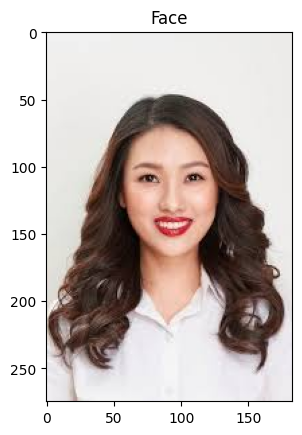

In [2]:
# Load the Face Image
faceImage = cv2.imread('img.JPG')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(275, 183, 3)

Text(0.5, 1.0, 'glassPNG')

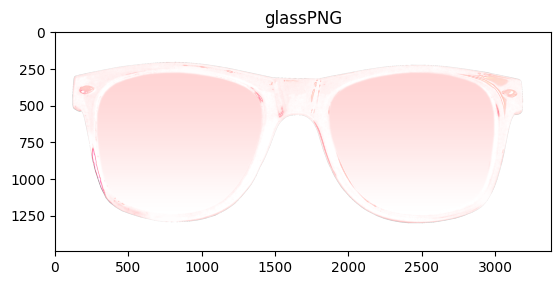

In [4]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('specs.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [5]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [6]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

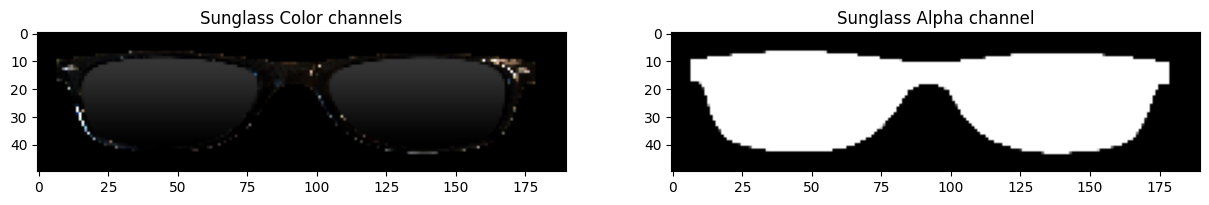

In [7]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

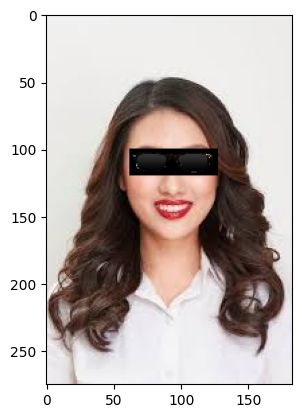

In [18]:
# Make a copy
#faceWithGlassesNaive = resized_faceImage.copy()
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region with the sunglass image
faceWithGlassesNaive[100:120, 62:128] = cv2.resize(glassBGR, (128-62,120-100))

plt.imshow(faceWithGlassesNaive[...,::-1])

Text(0.5, 1.0, 'Final Output')

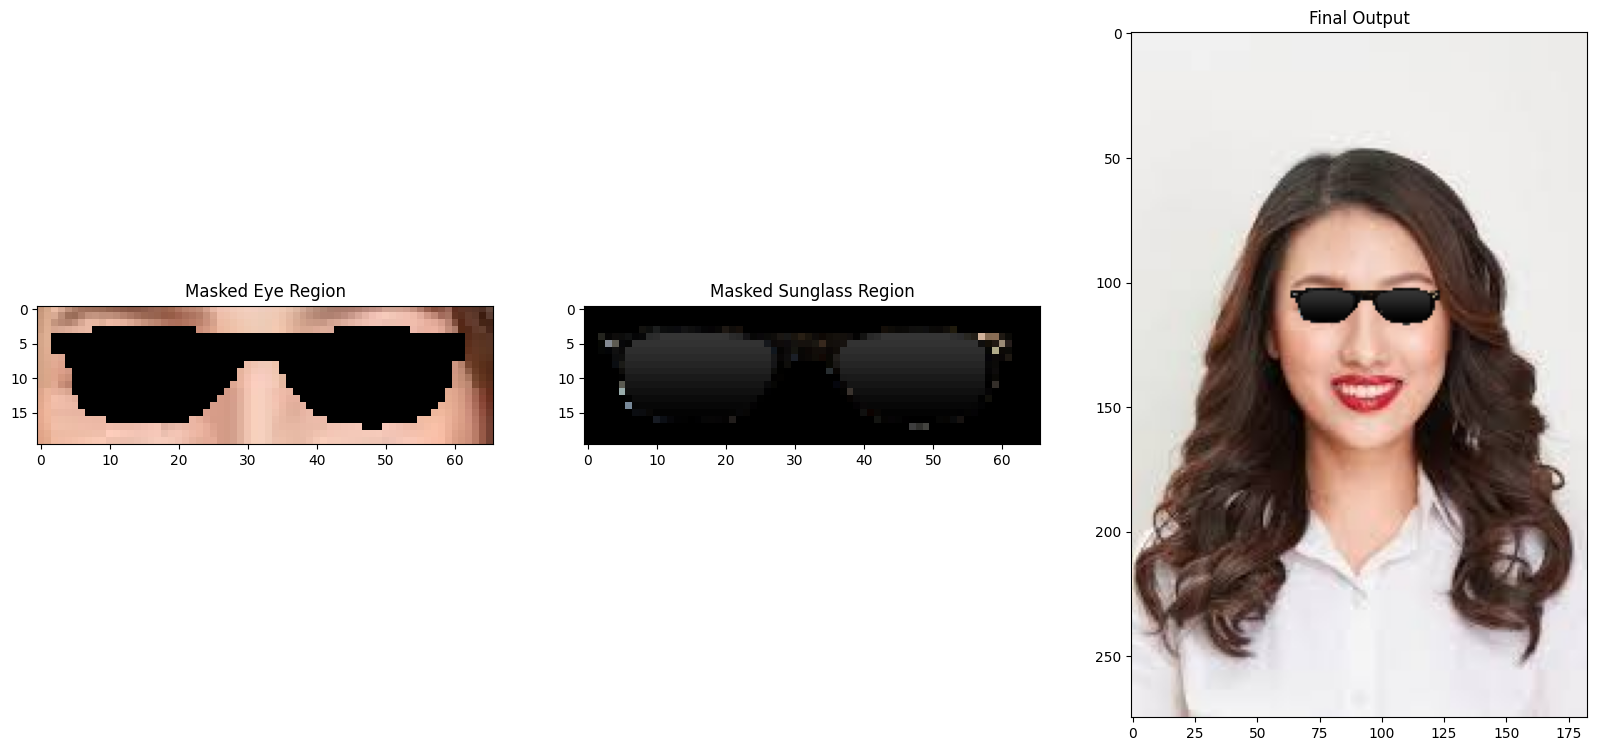

In [19]:
# Make the dimensions of the mask same as the input image
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))
glassMask = np.uint8(glassMask / 255)

# Make a copy
faceWithGlassesArithmetic = faceImage.copy()

# Correct eye region (within 183 width)
y1, y2 = 100, 120
x1, x2 = 62, 128

# Resize glass and mask to match ROI
glass_resized = cv2.resize(glassBGR, (x2 - x1, y2 - y1))
mask_resized = cv2.resize(glassMask, (x2 - x1, y2 - y1))

# Get ROI
eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Apply mask
maskedEye = cv2.multiply(eyeROI, (1 - mask_resized))
maskedGlass = cv2.multiply(glass_resized, mask_resized)

# Combine
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Put back into image
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# Display
plt.figure(figsize=[20,20])
plt.subplot(131); plt.imshow(maskedEye[...,::-1]); plt.title("Masked Eye Region")
plt.subplot(132); plt.imshow(maskedGlass[...,::-1]); plt.title("Masked Sunglass Region")
plt.subplot(133); plt.imshow(faceWithGlassesArithmetic[...,::-1]); plt.title("Final Output")

Text(0.5, 1.0, 'With Sunglasses')

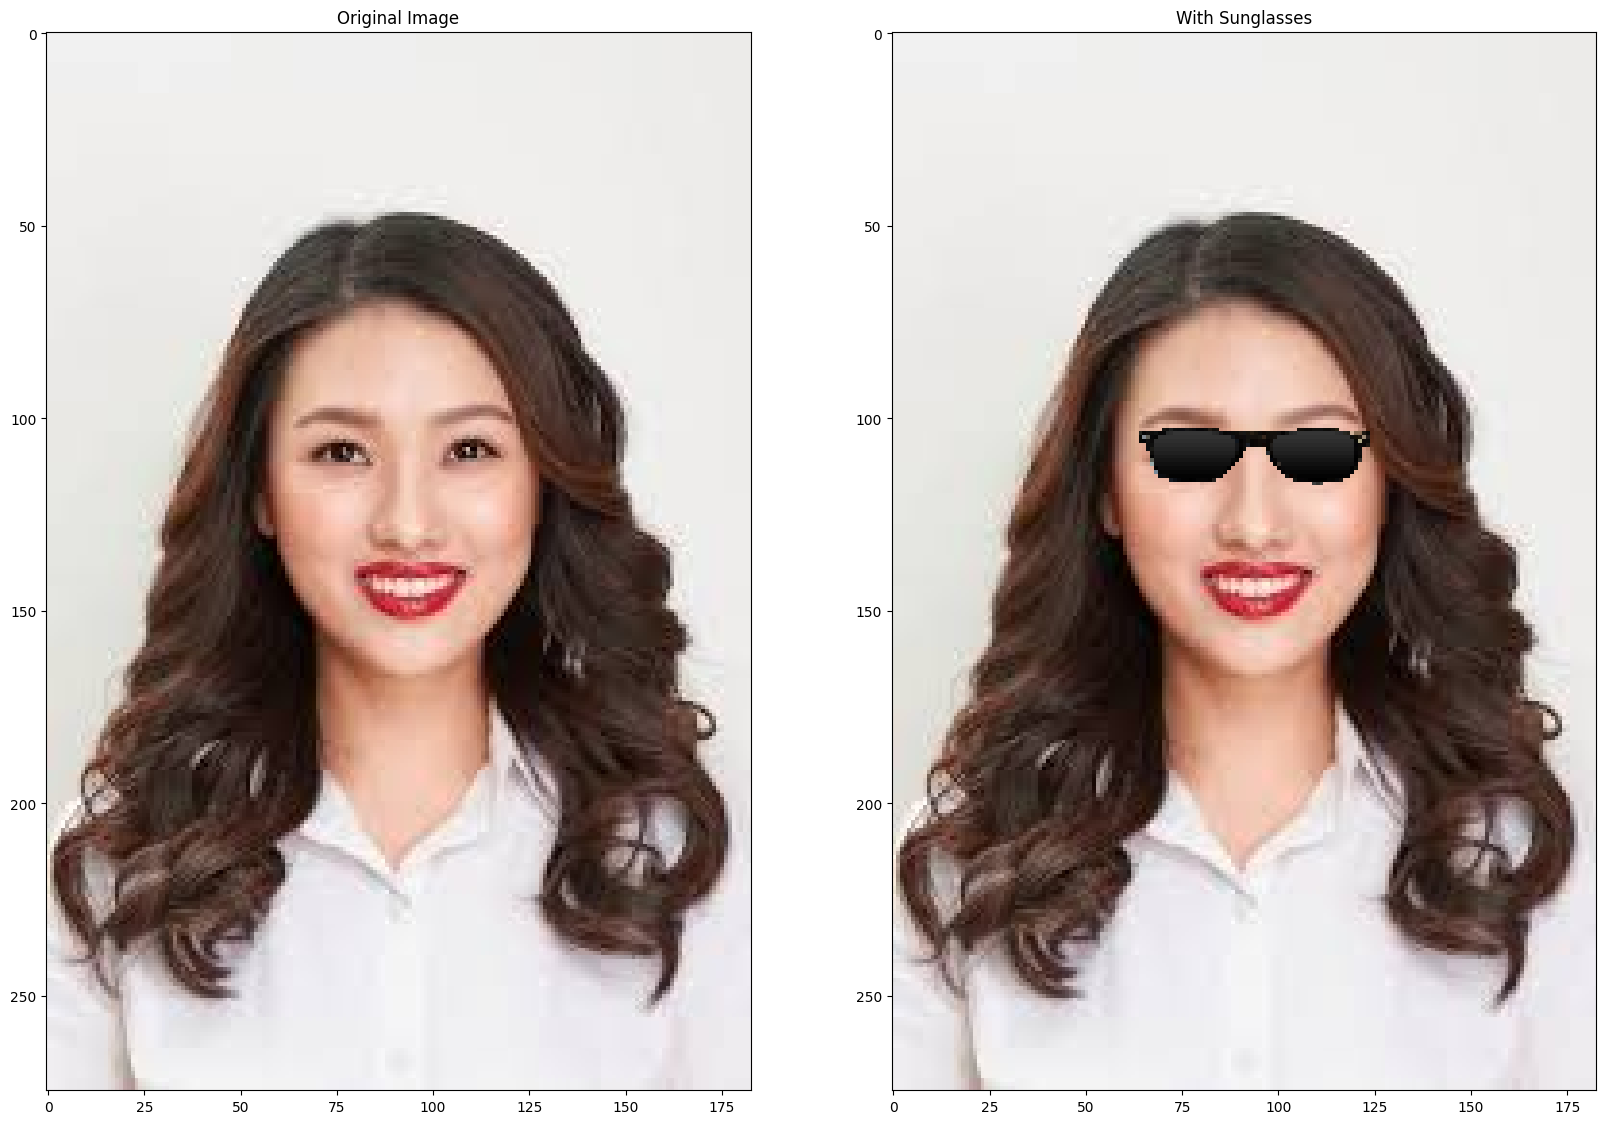

In [21]:
faceWithGlassesArithmetic[100:120, 62:128] = eyeRoiFinal

plt.figure(figsize=[20,20])
plt.subplot(121); plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(faceWithGlassesArithmetic[:,:,::-1]); plt.title("With Sunglasses")